In [1]:
#import necessary files

import pandas as pd
file_path = r"C:\D_Drive\Reshma\MITSDE\datasetandpresentationfrom9thmarchsession\daily-minimum-temperatures-in-me.csv"
df = pd.read_csv(file_path)

print (df.head())

         Date  Daily minimum temperatures
0  01-01-1981                        20.7
1  01-02-1981                        17.9
2  01-03-1981                        18.8
3  01-04-1981                        14.6
4  01-05-1981                        15.8


In [2]:
print (df.tail())

            Date  Daily minimum temperatures
3645  12-27-1990                        14.2
3646  12-28-1990                        13.6
3647  12-29-1990                        13.5
3648  12-30-1990                        15.7
3649  12-31-1990                        13.2


In [3]:
print (df.dtypes)

Date                           object
Daily minimum temperatures    float64
dtype: object


In [4]:

df["Date"] = pd.to_datetime(df["Date"])
print (df.dtypes)

Date                          datetime64[ns]
Daily minimum temperatures           float64
dtype: object


In [5]:
df.rename(columns={"Daily minimum temperatures": "Mintemp"}, inplace=True)

In [6]:
df.columns

Index(['Date', 'Mintemp'], dtype='object')

In [7]:
df.isna().sum()

Date       0
Mintemp    0
dtype: int64

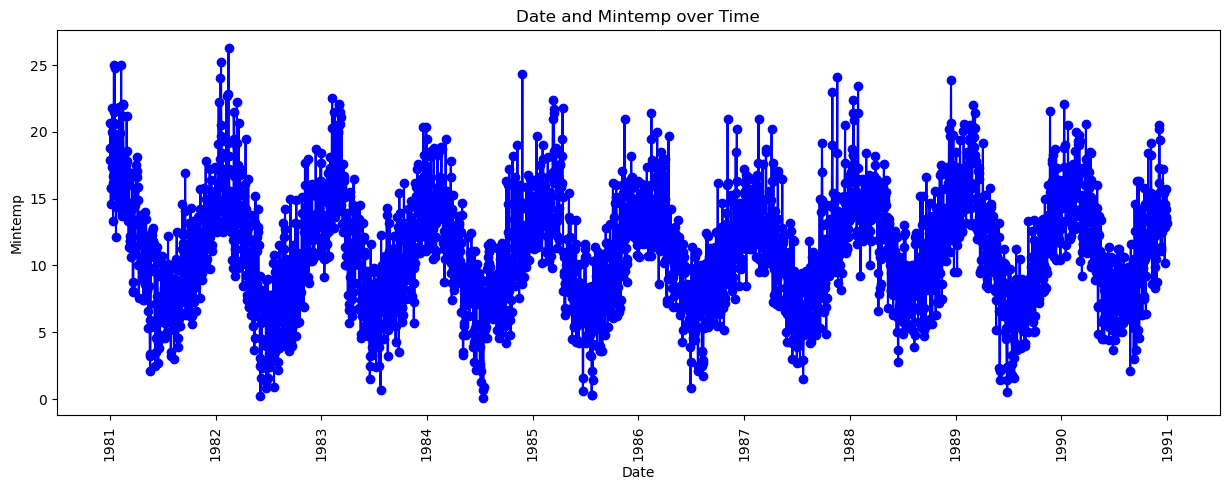

In [8]:
#visual inspection for stationary and trend
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(df["Date"], df["Mintemp"], marker="o" ,linestyle="-", color="b")

plt.xlabel("Date")
plt.ylabel("Mintemp")

plt.title("Date and Mintemp over Time")
plt.xticks(rotation=90)
plt.show()


In [9]:
df.set_index("Date", inplace=True)

In [10]:
print(df.isnull().sum())

Mintemp    0
dtype: int64


In [11]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test
adf_result = adfuller(df["Mintemp"])

# Print the results
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

# Interpretation
if adf_result[1] < 0.05:
    print("The data is stationary (Reject Null Hypothesis).")
else:
    print("The data is NOT stationary (Fail to Reject Null Hypothesis).")


ADF Statistic: -4.429489465405983
p-value: 0.00026312352165886637
Critical Values: {'1%': -3.4321532327220154, '5%': -2.862336767636517, '10%': -2.56719413172842}
The data is stationary (Reject Null Hypothesis).


In [12]:
from statsmodels.tsa.stattools import adfuller

# Apply first-order differencing
df["Mintemp_diff"] = df["Mintemp"].diff()

# Drop the first NaN value after differencing
df.dropna(inplace=True)

# Perform ADF test again
adf_result = adfuller(df["Mintemp_diff"])

# Print results
print("ADF Statistic after Differencing:", adf_result[0])
print("p-value after Differencing:", adf_result[1])

if adf_result[1] < 0.05:
    print("The data is now stationary (Reject Null Hypothesis).")
else:
    print("The data is still not stationary (Further differencing may be needed).")



ADF Statistic after Differencing: -21.18466097617454
p-value after Differencing: 0.0
The data is now stationary (Reject Null Hypothesis).


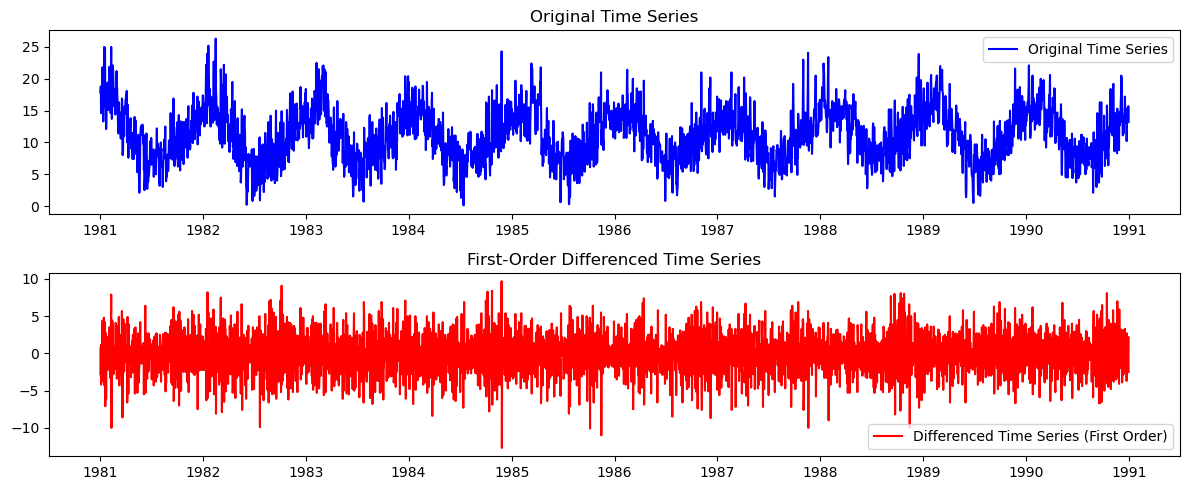

In [13]:
# Step 6: Visualization of differenced and non differenced data 
import matplotlib.pyplot as plt

# Plot original series
plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.plot(df["Mintemp"], label="Original Time Series", color="blue")
plt.title("Original Time Series")
plt.legend()

# Plot differenced series
plt.subplot(2, 1, 2)
plt.plot(df["Mintemp_diff"], label="Differenced Time Series (First Order)", color="red")
plt.title("First-Order Differenced Time Series")
plt.legend()

plt.tight_layout()
plt.show()